In [6]:
import pandas as pd
import numpy as np

feats = pd.read_csv("../../dataset/match_features_merged.csv")
labels = pd.read_csv("../../cleaned_data/final_dataset.csv",
                     usecols=["game_id", "result", "home_club_id", "away_club_id"])

df = feats.merge(labels, on="game_id")

# keep only rows we can classify
label_map = {"Home Win": 0, "Draw": 1, "Away Win": 2}
df = df[df["result"].isin(label_map)]

print(df.shape)
print("label counts:\n", df["result"].value_counts())

(59605, 57)
label counts:
 result
Home Win    26891
Away Win    18429
Draw        14285
Name: count, dtype: int64


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1 · build raw feature frame (no cleaning yet)
raw_X = df.drop(columns=["game_id", "result"])

# --- count bad values BEFORE cleaning -----------------
n_nan = raw_X.isna().sum().sum()
n_inf = np.isinf(raw_X.values).sum()
print(f"before  –  NaN:{n_nan:,}   ±inf:{n_inf:,}")

# --- clean -------------------------------------------
X_df = (
    raw_X.replace([np.inf, -np.inf], np.nan)          # turn ±inf → NaN
         .fillna(raw_X.mean(numeric_only=True))       # mean-impute
)

# --- count AFTER cleaning ----------------------------
n_nan2 = X_df.isna().sum().sum()
n_inf2 = np.isinf(X_df.values).sum()
print(f"after   –  NaN:{n_nan2:,}   ±inf:{n_inf2:,}")

# 2 · labels -------------------------------------------
y = df["result"].map({"Home Win": 0, "Draw": 1, "Away Win": 2}).astype("int8")

# 3 · split & scale -----------------------------------
X_tr, X_te, y_tr, y_te = train_test_split(
    X_df.values.astype(float), y,
    test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler().fit(X_tr)
X_tr = scaler.transform(X_tr)
X_te = scaler.transform(X_te)

# 4 · final safety pass -------------------------------
X_tr = np.nan_to_num(X_tr, nan=0.0, posinf=0.0, neginf=0.0)
X_te = np.nan_to_num(X_te, nan=0.0, posinf=0.0, neginf=0.0)


# extreme lange fix (-33~51)
CLIP = 7          # ±10 → exp(±10) ≈ 2.2 × 10⁴  (still safe)

X_tr = np.clip(X_tr, -CLIP, CLIP)
X_te = np.clip(X_te, -CLIP, CLIP)

print("train-shape:", X_tr.shape,
      "finite?",    np.isfinite(X_tr).all(),
      "min/max:",   X_tr.min(), X_tr.max())

before  –  NaN:0   ±inf:0
after   –  NaN:0   ±inf:0
train-shape: (47684, 55) finite? True min/max: -7.0 7.0


In [8]:

import pymc as pm
import pytensor.tensor as pt

print(df.keys())
home_id_tr = pd.Categorical(df['home_club_id']).codes
away_id_tr = pd.Categorical(df['away_club_id']).codes

n_teams = home_id_tr.max() + 1          # total clubs

with pm.Model() as hierarchical_logit:
    # shared data
    X_ = pm.MutableData("X", X_tr)
    h_idx = pm.MutableData("home_idx",  home_id_tr)
    a_idx = pm.MutableData("away_idx",  away_id_tr)

    # global coefficients
    beta = pm.Normal("beta",  0, 0.5, shape=(k, 2))
    intercept = pm.Normal("intercept", 0, 0.5, shape=2)

    # team random effects
    tau = pm.HalfNormal("tau", 1.0)                    # sd of strengths
    s = pm.Normal("team_strength", 0, tau, shape=n_teams)

    # linear predictor
    eta = intercept + pt.dot(X_, beta) + s[h_idx, None] - s[a_idx, None]
    eta_full = pt.concatenate([pt.zeros_like(eta[:, :1]), eta], axis=1)

    p = pm.Deterministic("p", pm.math.softmax(eta_full))
    y = pm.Categorical("y", logit_p=eta_full, observed=y_tr)

    trace = pm.sample(draws=1_000, tune=1_000, target_accept=0.9,
                      chains=4, cores=4, init="jitter+adapt_diag")

Index(['game_id', 'rest_days_home', 'long_break_flag_home', 'rest_days_away',
       'long_break_flag_away', 'rest_days_diff', 'long_break_flag_diff',
       'season_ppg_home', 'season_ppg_away', 'season_ppg_diff',
       'goal_diff_pg_home', 'goal_diff_pg_away', 'goal_diff_pg_diff',
       'win_rate_last5_home', 'win_rate_last5_away', 'win_rate_last5_diff',
       'manager_tenure_home', 'manager_tenure_away', 'manager_tenure_diff',
       'avg_age_home', 'avg_age_away', 'avg_age_diff', 'avg_age_home_missing',
       'avg_age_away_missing', 'squad_value_home', 'squad_value_away',
       'squad_value_diff', 'squad_value_home_missing',
       'squad_value_away_missing', 'foreign_ratio_home', 'foreign_ratio_away',
       'foreign_ratio_diff', 'h2h_win_rate_home', 'h2h_goal_diff',
       'home_team_flag', 'attendance_ratio', 'attendance_missing',
       'matchday_idx', 'league_tier', 'home_avg_market_value',
       'away_avg_market_value', 'home_avg_market_value_missing',
       'away_avg_

/opt/homebrew/Caskroom/miniforge/base/envs/pgm/lib/python3.11/site-packages/pymc/data.py:321: FutureWarning: MutableData is deprecated. All Data variables are now mutable. Use Data instead.
  warnings.warn(


NameError: name 'k' is not defined

<Axes: >

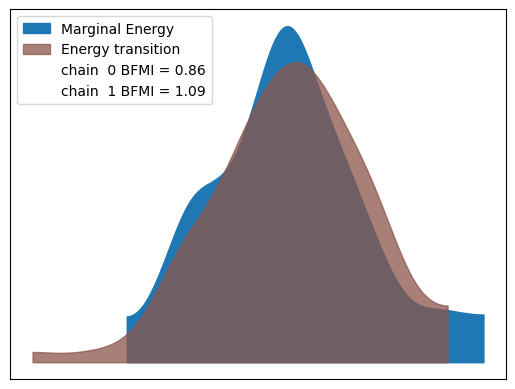

In [ ]:
# verify sampled data
import arviz as az
az.summary(trace, var_names=["beta", "intercept"])
az.plot_energy(trace)        # Monte-Carlo standard error & divergences

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
with flat_logit:
    X_.set_value(X_te)                       # swap test matrix
    ppc = pm.sample_posterior_predictive(
        trace, var_names=["p"], return_inferencedata=False)


p_mean = ppc["p"].mean(axis=(0, 1))
y_pred = np.argmax(p_mean, axis=1).astype(np.int8)

print(classification_report(y_te, y_pred, digits=3))
print(confusion_matrix(y_te, y_pred))

/var/folders/8j/f7hry10s1sgf5dmy023w1qm40000gn/T/ipykernel_37560/2892959423.py:4: UserWarning: The effect of Potentials on other parameters is ignored during posterior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  ppc = pm.sample_posterior_predictive(
Sampling: []


Output()

              precision    recall  f1-score   support

           0      0.642     0.573     0.606      5378
           1      0.295     0.304     0.299      2857
           2      0.500     0.567     0.531      3686

    accuracy                          0.507     11921
   macro avg      0.479     0.481     0.479     11921
weighted avg      0.515     0.507     0.509     11921

[[3081 1209 1088]
 [ 990  869  998]
 [ 727  870 2089]]
